# Strassen Matrix Multiplication: Comparison

## Aim
Compare:

1. **Brute-force matrix multiplication**;
2. **Strassen's divide-and-conquer algorithm**;
3. **NumPy built-in multiplication** `A @ B`.

## Mathematics
For

$$A=\begin{bmatrix}A_{11}&A_{12}\\A_{21}&A_{22}\end{bmatrix}, \qquad
B=\begin{bmatrix}B_{11}&B_{12}\\B_{21}&B_{22}\end{bmatrix},$$

Strassen computes seven products:

$$\begin{aligned}
M_1&=(A_{11}+A_{22})(B_{11}+B_{22}),\\
M_2&=(A_{21}+A_{22})B_{11},\\
M_3&=A_{11}(B_{12}-B_{22}),\\
M_4&=A_{22}(B_{21}-B_{11}),\\
M_5&=(A_{11}+A_{12})B_{22},\\
M_6&=(A_{21}-A_{11})(B_{11}+B_{12}),\\
M_7&=(A_{12}-A_{22})(B_{21}+B_{22}).
\end{aligned}$$

The result is

$$\begin{aligned}
C_{11}&=M_1+M_4-M_5+M_7, & C_{12}&=M_3+M_5,\\
C_{21}&=M_2+M_4, & C_{22}&=M_1-M_2+M_3+M_6.
\end{aligned}$$

Brute force requires $\Theta(n^3)$ operations. Strassen satisfies

$$T(n)=7T(n/2)+\Theta(n^2)=\Theta\left(n^{\log_2 7}\right)\approx\Theta(n^{2.807}).$$


## Before running the code

The code uses square matrices whose orders are powers of two. It checks all answers against `A @ B`, measures mean time, and compares the three methods graphically.


In [4]:
import time, statistics
import numpy as np
import matplotlib.pyplot as plt

SEED=20260907
SIZES=[4,8,16,32,64]
REPEATS=3
CUTOFF=8
rng=np.random.default_rng(SEED)

def brute_force(A,B):
    n=A.shape[0]; C=np.zeros((n,n),dtype=np.int64)
    for i in range(n):
        for j in range(n):
            for k in range(n): C[i,j] = C[i,j] + A[i,k]*B[k,j]
    return C

def strassen(A,B,cutoff=CUTOFF):  # cutoff is the matrix size threshold below which standard multiplication is used
    n=A.shape[0]
    if n<=cutoff: return brute_force(A,B)
    h=n//2
    A11,A12,A21,A22=A[:h,:h],A[:h,h:],A[h:,:h],A[h:,h:]
    B11,B12,B21,B22=B[:h,:h],B[:h,h:],B[h:,:h],B[h:,h:]
    M1=strassen(A11+A22,B11+B22,cutoff); 
    M2=strassen(A21+A22,B11,cutoff);
    M3=strassen(A11,B12-B22,cutoff); 
    M4=strassen(A22,B21-B11,cutoff);
    M5=strassen(A11+A12,B22,cutoff); 
    M6=strassen(A21-A11,B11+B12,cutoff);
    M7=strassen(A12-A22,B21+B22,cutoff);
    return np.block([[M1+M4-M5+M7,M3+M5],[M2+M4,M1-M2+M3+M6]])

def mean_time(f,A,B,repeats=REPEATS):
    times=[]; C=None
    for _ in range(repeats):
        start=time.perf_counter(); C=f(A,B); times.append(time.perf_counter()-start)
    return statistics.mean(times),C


In [5]:
rows=[]
for n in SIZES:
    A=rng.integers(-5,6,(n,n),dtype=np.int64); B=rng.integers(-5,6,(n,n),dtype=np.int64)
    tb,C1=mean_time(brute_force,A,B); ts,C2=mean_time(strassen,A,B); tn,C3=mean_time(lambda X,Y:X@Y,A,B)
    assert np.array_equal(C1,C2) and np.array_equal(C1,C3)
    rows.append((n,tb,ts,tn)); print(f'n={n:3d}: brute={tb:.6e}, Strassen={ts:.6e}, built-in={tn:.6e}')


n=  4: brute=2.306667e-05, Strassen=2.140000e-05, built-in=3.233333e-06
n=  8: brute=1.463667e-04, Strassen=1.442667e-04, built-in=1.233334e-06
n= 16: brute=1.134800e-03, Strassen=1.054233e-03, built-in=3.900000e-06
n= 32: brute=8.914133e-03, Strassen=7.265867e-03, built-in=6.233333e-05
n= 64: brute=7.390273e-02, Strassen=5.936107e-02, built-in=2.759667e-04


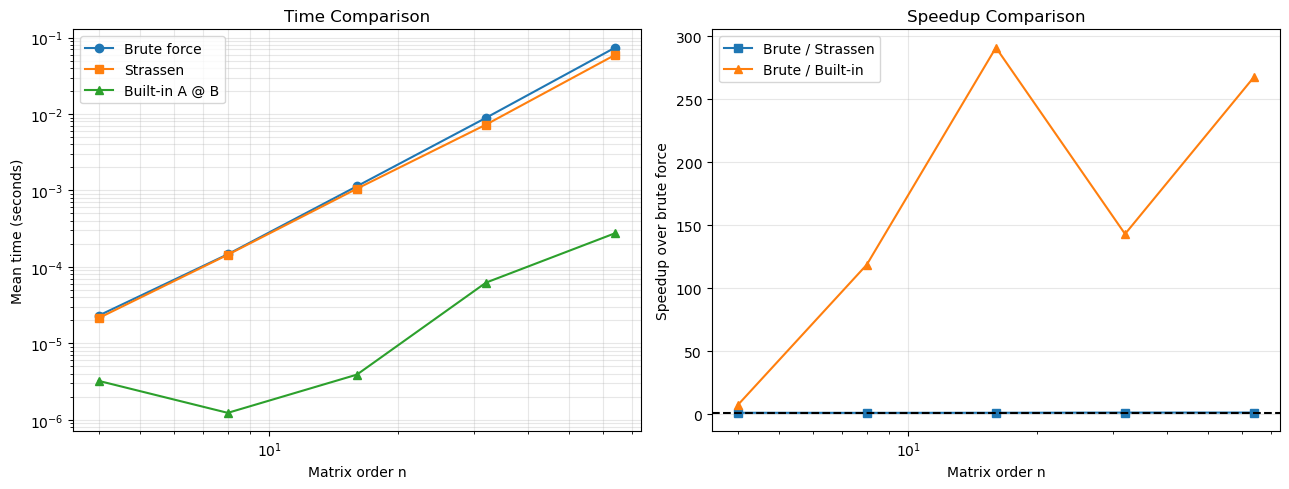

In [6]:
n=[r[0] for r in rows]; tb=[r[1] for r in rows]; ts=[r[2] for r in rows]; tn=[r[3] for r in rows]
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].loglog(n,tb,'o-',label='Brute force'); ax[0].loglog(n,ts,'s-',label='Strassen'); ax[0].loglog(n,tn,'^-',label='Built-in A @ B')
ax[0].set(xlabel='Matrix order n',ylabel='Mean time (seconds)',title='Time Comparison'); ax[0].grid(True,which='both',alpha=.3); ax[0].legend()
ax[1].semilogx(n,[b/s for b,s in zip(tb,ts)],'s-',label='Brute / Strassen'); ax[1].semilogx(n,[b/u for b,u in zip(tb,tn)],'^-',label='Brute / Built-in')
ax[1].axhline(1,color='black',ls='--'); ax[1].set(xlabel='Matrix order n',ylabel='Speedup over brute force',title='Speedup Comparison'); ax[1].grid(True,alpha=.3); ax[1].legend()
plt.tight_layout(); plt.show()


### Meaning of the graphs

- The lowest curve in the time graph is fastest.
- In the speedup graph, a value of $50$ means that Strassen is 50 times faster than brute force matrix multiplication.
- Strassen saves one recursive block multiplication, but performs extra block additions and creates intermediate arrays.
- `A @ B` is usually fastest because its main loops run in optimized compiled numerical code.


## Two exercises

### Exercise 1: Verify seven products
Use two $2\times2$ matrices. Program $M_1,\ldots,M_7$ and reconstruct $C$. Verify the answer using `A @ B`.

### Exercise 2: Compare the methods
For $n=8,16,32,64$, plot the mean times of brute force and Strassen. Print $t_B/t_S$ and identify the values of $n$ for which Strassen is faster.


In [10]:
A = np.array([[1, 2], 
              [3, 4]], dtype=np.int64)

B = np.array([[5, 6], 
              [7, 8]], dtype=np.int64)

A11, A12, A21, A22 = A[0, 0], A[0, 1], A[1, 0], A[1, 1]
B11, B12, B21, B22 = B[0, 0], B[0, 1], B[1, 0], B[1, 1]

M1 = (A11 + A22) * (B11 + B22)
M2 = (A21 + A22) * B11
M3 = A11 * (B12 - B22)
M4 = A22 * (B21 - B11)
M5 = (A11 + A12) * B22
M6 = (A21 - A11) * (B11 + B12)
M7 = (A12 - A22) * (B21 + B22)

print(f"M1: {M1}, M2: {M2}, M3: {M3}, M4: {M4}, M5: {M5}, M6: {M6}, M7: {M7}")

C11 = M1 + M4 - M5 + M7
C12 = M3 + M5
C21 = M2 + M4
C22 = M1 - M2 + M3 + M6

C_strassen = np.array([[C11, C12], 
                       [C21, C22]], dtype=np.int64)

C_builtin = A @ B

print("\nReconstructed Matrix C (Strassen):\n", C_strassen)
print("Actual Product Matrix C (A @ B):\n", C_builtin)
print("Match Verified:", np.array_equal(C_strassen, C_builtin))

M1: 65, M2: 35, M3: -2, M4: 8, M5: 24, M6: 22, M7: -30

Reconstructed Matrix C (Strassen):
 [[19 22]
 [43 50]]
Actual Product Matrix C (A @ B):
 [[19 22]
 [43 50]]
Match Verified: True


n= 8 | brute=1.503333e-04s | Strassen=2.286667e-04s | tB/tS=0.66
n=16 | brute=1.984667e-03s | Strassen=1.777267e-03s | tB/tS=1.12
n=32 | brute=1.284707e-02s | Strassen=7.266033e-03s | tB/tS=1.77
n=64 | brute=6.910443e-02s | Strassen=5.140097e-02s | tB/tS=1.34

Strassen is faster (tB / tS > 1) at matrix orders n = [16, 32, 64]


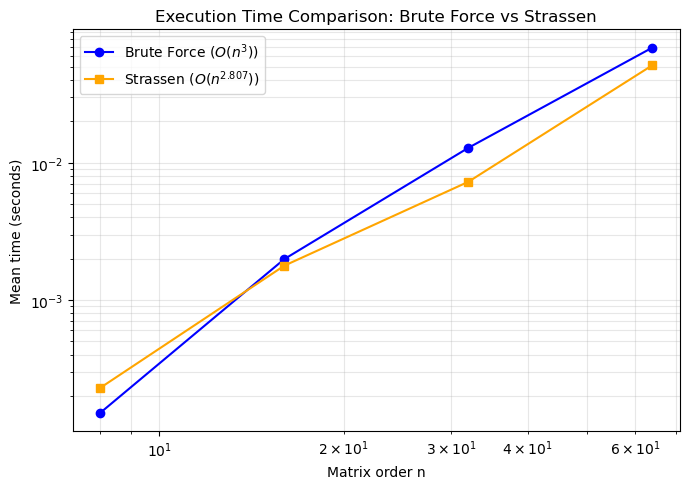

In [8]:
CUTOFF = 8
REPEATS = 3
SIZES = [8, 16, 32, 64]


rows = []
for n in SIZES:
    A = rng.integers(-5, 6, (n, n), dtype=np.int64)
    B = rng.integers(-5, 6, (n, n), dtype=np.int64)
    
    tb, C1 = mean_time(brute_force, A, B)
    ts, C2 = mean_time(strassen, A, B)
    assert np.array_equal(C1, C2)
    
    ratio = tb / ts
    rows.append((n, tb, ts, ratio))
    print(f'n={n:2d} | brute={tb:.6e}s | Strassen={ts:.6e}s | tB/tS={ratio:.2f}')

# Values of n where Strassen is faster (tB / tS > 1)
faster_sizes = [r[0] for r in rows if r[3] > 1.0]
print(f"\nStrassen is faster (tB / tS > 1) at matrix orders n = {faster_sizes}")

# Single Plot: Mean Times of Brute Force vs Strassen
n_vals = [r[0] for r in rows]
tb_vals = [r[1] for r in rows]
ts_vals = [r[2] for r in rows]

plt.figure(figsize=(7, 5))
plt.loglog(n_vals, tb_vals, 'o-', color='blue', label='Brute Force ($O(n^3)$)')
plt.loglog(n_vals, ts_vals, 's-', color='orange', label='Strassen ($O(n^{2.807})$)')

plt.xlabel('Matrix order n')
plt.ylabel('Mean time (seconds)')
plt.title('Execution Time Comparison: Brute Force vs Strassen')
plt.grid(True, which='both', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()